In [1]:
import torch
import numpy as np
from BFM.MCMC_LH import Gibbs_sampling
from BFM.utils import check_marginal_HDI_mcmc
from scipy.stats import t
import matplotlib.pyplot as plt

In [2]:
X = np.load('lung.npy')

In [3]:
device1 = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
B_sample, eta_sample, sigma2_sample = Gibbs_sampling(X, device = device1, score = True)

100%|██████████| 9999/9999 [26:41<00:00,  6.25it/s]


In [5]:
B_mean = torch.mean(B_sample, axis = 0)
eta_mean = torch.mean(eta_sample, axis = 0).detach().numpy()

In [7]:
Carcinoid = eta_mean[:,0:20]
Colon = eta_mean[:,20:33]
Normal = eta_mean[:,33:50]
SmallCell  = eta_mean[:,50:56]

In [8]:
zero = check_marginal_HDI_mcmc(B_sample, 0.95)

In [9]:
(5000 - zero.sum(axis = 0)) / 5000

array([0.399 , 0.3434, 0.184 , 0.1778, 0.208 , 0.1086, 0.1272, 0.1634,
       0.051 , 0.0202, 0.0506, 0.0332, 0.0428, 0.0348, 0.018 , 0.0108,
       0.0214, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    ])

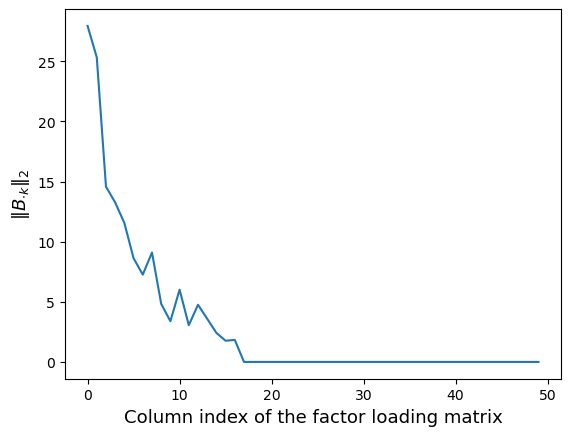

In [10]:
plt.plot(torch.norm(B_mean, dim = 0))
plt.xlabel('Column index of the factor loading matrix',fontsize=13)
plt.ylabel(r'$\|B_{\cdot k}\|_{2}$', fontsize=13)
plt.savefig('MCMC_LH_norm_B.png')
plt.show()

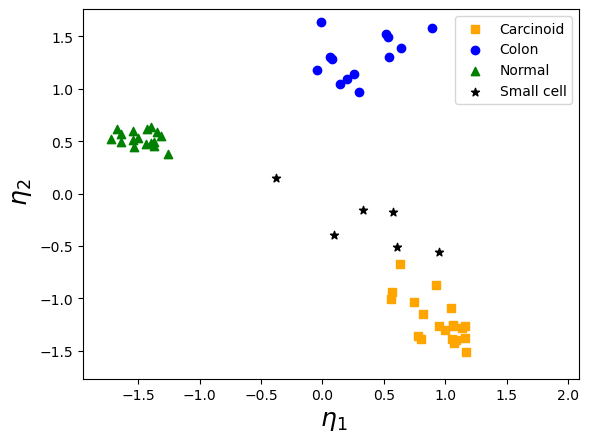

In [15]:
fig, axs = plt.subplots(1, 1)

# First subplot
axs.scatter(Carcinoid[0,:], Carcinoid[1,:], c='orange', marker='s', label='Carcinoid')
axs.scatter(Colon[0,:], Colon[1,:], c='blue', marker='o', label='Colon')
axs.scatter(Normal[0,:], Normal[1,:], c='green', marker='^', label='Normal')
axs.scatter(SmallCell[0,:], SmallCell[1,:], c='black', marker='*', label='Small cell')

# Expand axes by 10–20% beyond data range
margin = 0.40  # 15% padding
x_data = np.concatenate([Carcinoid[0,:], Colon[0,:], Normal[0,:], SmallCell[0,:]])
y_data = np.concatenate([Carcinoid[1,:], Colon[1,:], Normal[1,:], SmallCell[1,:]])
x_min, x_max = x_data.min(), x_data.max()
y_min, y_max = y_data.min(), y_data.max()
x_range = x_max - x_min
y_range = y_max - y_min

axs.set_xlim(x_min - 0.2 * margin * x_range, x_max + 0.8 * margin * x_range)
axs.set_ylim(y_min - 0.2 * margin * y_range, y_max + 0.1 * margin * y_range)

axs.set_xlabel(r' $ \eta_1 $ ', fontsize=18, fontweight='bold')
axs.set_ylabel(r' $ \eta_2 $ ', fontsize=18, fontweight='bold')
axs.legend(loc='upper right')

plt.show()